# 泰勒展开与梯度下降收敛直觉 - 可视化

本 Notebook 生成三张图：
1. 函数与泰勒一阶/二阶近似
2. 不同学习率下的参数轨迹
3. 不同学习率下的损失下降曲线

输出目录：`assets/`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

assets_dir = Path.cwd() / 'assets'
assets_dir.mkdir(parents=True, exist_ok=True)
assets_dir

WindowsPath('D:/BBFEC-FRONT/RL-AND-RL/01_数学基础/01_微积分/assets')

## 图1：函数与泰勒近似

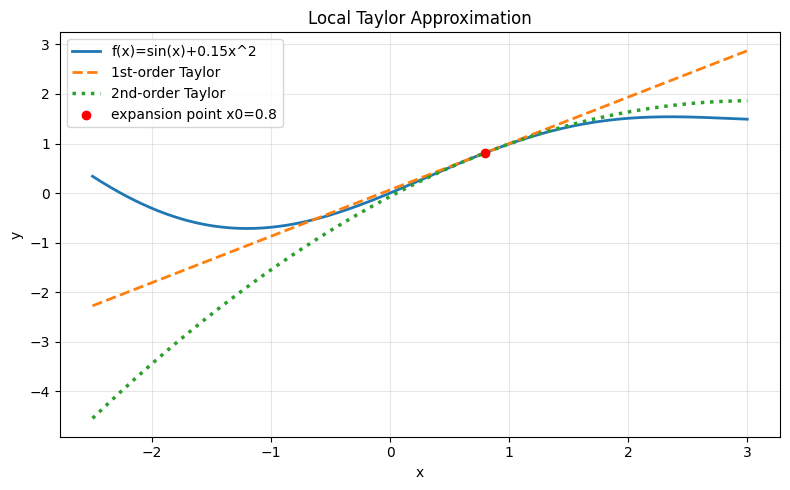

In [2]:
# 选一个非线性函数做局部近似演示
f = lambda x: np.sin(x) + 0.15*x**2
df = lambda x: np.cos(x) + 0.3*x
ddf = lambda x: -np.sin(x) + 0.3

x0 = 0.8
x = np.linspace(-2.5, 3.0, 500)

f0 = f(x0)
d1 = df(x0)
d2 = ddf(x0)

t1 = f0 + d1*(x-x0)
t2 = f0 + d1*(x-x0) + 0.5*d2*(x-x0)**2

plt.figure(figsize=(8,5))
plt.plot(x, f(x), label='f(x)=sin(x)+0.15x^2', linewidth=2)
plt.plot(x, t1, '--', label='1st-order Taylor', linewidth=2)
plt.plot(x, t2, ':', label='2nd-order Taylor', linewidth=2.5)
plt.scatter([x0],[f0], c='red', zorder=5, label=f'expansion point x0={x0}')
plt.title('Local Taylor Approximation')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(assets_dir / '07_taylor_approx.png', dpi=160)
plt.show()

## 图2：不同学习率下参数轨迹（f(w)=0.5w^2）

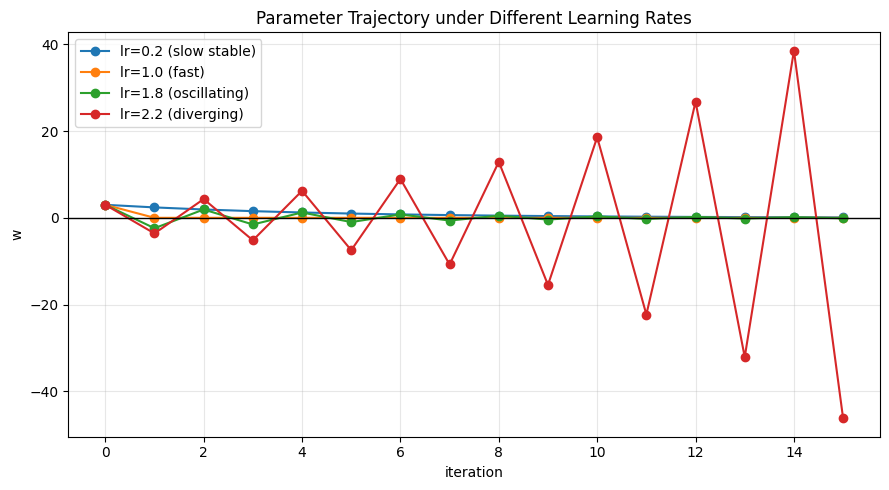

In [3]:
def loss(w):
    return 0.5*w**2

def grad(w):
    return w

def run_gd(w0, lr, steps=20):
    ws = [w0]
    for _ in range(steps):
        w0 = w0 - lr*grad(w0)
        ws.append(w0)
    return np.array(ws)

w0 = 3.0
lrs = [0.2, 1.0, 1.8, 2.2]
labels = ['lr=0.2 (slow stable)', 'lr=1.0 (fast)', 'lr=1.8 (oscillating)', 'lr=2.2 (diverging)']

plt.figure(figsize=(9,5))
for lr, label in zip(lrs, labels):
    ws = run_gd(w0, lr, steps=15)
    plt.plot(ws, marker='o', label=label)

plt.axhline(0, color='black', linewidth=1)
plt.title('Parameter Trajectory under Different Learning Rates')
plt.xlabel('iteration')
plt.ylabel('w')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(assets_dir / '08_lr_convergence.png', dpi=160)
plt.show()

## 图3：不同学习率下损失曲线

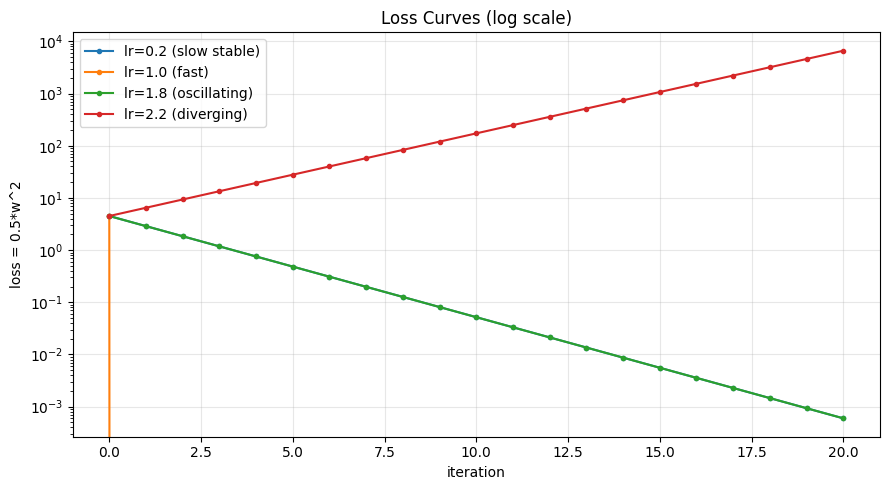

In [4]:
plt.figure(figsize=(9,5))
for lr, label in zip(lrs, labels):
    ws = run_gd(w0, lr, steps=20)
    ls = loss(ws)
    plt.plot(ls, marker='.', label=label)

plt.yscale('log')
plt.title('Loss Curves (log scale)')
plt.xlabel('iteration')
plt.ylabel('loss = 0.5*w^2')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(assets_dir / '09_loss_curve_lr_compare.png', dpi=160)
plt.show()

### 输出文件
- `assets/07_taylor_approx.png`
- `assets/08_lr_convergence.png`
- `assets/09_loss_curve_lr_compare.png`